<a href="https://colab.research.google.com/github/MarianaCelisBougard/Taller_NNA_Grupo4/blob/main/Data_Understanding/Data_Understanding_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
"""
==============================================================================
CRISP-DM FASE 2: DATA UNDERSTANDING - Análisis Exploratorio de Datos (EDA)
Proyecto: Caracterización de NNA en Programas de Intervención
Notebook 1 de 2
==============================================================================
"""

# ==============================================================================
# 1. CONFIGURACIÓN INICIAL Y CARGA DE LIBRERÍAS
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("CRISP-DM FASE 2: DATA UNDERSTANDING (EDA)")
print("Proyecto: Caracterización de NNA en Trabajo Infantil")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRISP-DM FASE 2: DATA UNDERSTANDING (EDA)
Proyecto: Caracterización de NNA en Trabajo Infantil
Fecha de ejecución: 2025-10-15 21:33:47


In [24]:
# ==============================================================================
# 2. CARGA DE DATOS ORIGINALES
# ==============================================================================

ruta = '/content/drive/MyDrive/Python/Proyecto NNA/base_datos_completa_NNA_TI_anon.xlsx'

print("\n Cargando datos desde:", ruta)

diccionario = pd.read_excel(ruta, sheet_name="variables")
datos = pd.read_excel(ruta, sheet_name="BD")

print(f"\n Datos cargados exitosamente")
print(f"   - Diccionario: {diccionario.shape[0]} variables documentadas")
print(f"   - Dataset: {datos.shape[0]:,} registros × {datos.shape[1]} columnas")
print(f"   - Memoria: {datos.memory_usage(deep=True).sum() / 1024**2:.2f} MB")






 Cargando datos desde: /content/drive/MyDrive/Python/Proyecto NNA/base_datos_completa_NNA_TI_anon.xlsx

 Datos cargados exitosamente
   - Diccionario: 174 variables documentadas
   - Dataset: 56,473 registros × 115 columnas
   - Memoria: 226.42 MB


In [25]:
# ==============================================================================
# 3. INSPECCIÓN DEL DICCIONARIO DE VARIABLES
# ==============================================================================

print("\n" + "=" * 80)
print("ANÁLISIS DEL DICCIONARIO DE VARIABLES")
print("=" * 80)

print("\nPrimeras 10 variables documentadas:")
print(diccionario.head(10).to_string())

# Verificar si hay columnas de clasificación
if 'tipo' in diccionario.columns or 'categoria' in diccionario.columns:
    tipo_col = 'tipo' if 'tipo' in diccionario.columns else 'categoria'
    print(f"\n📊 Clasificación de variables por {tipo_col}:")
    print(diccionario[tipo_col].value_counts())



ANÁLISIS DEL DICCIONARIO DE VARIABLES

Primeras 10 variables documentadas:
   Unnamed: 0          Unnamed: 1            Unnamed: 2                                                                                  Unnamed: 3 Unnamed: 4                                         Unnamed: 5
0         NaN            Variable  Cantidad de opciones                                                                         Opciones (hasta 10)     Status                                      Observaciones
1         NaN              Id_fic                  1000                                                                      Identificadores únicos         OK                                                NaN
2         NaN         Base_Origen                     5  dic24_mar25, MARZO2023_NOVI 2024, sep09_2022_mar2023, nov21_sep08_2022, marzo_octubre 2021         OK                                                NaN
3         NaN           Ficha_fic                  1000                             

In [26]:
# ==============================================================================
# 4. INFORMACIÓN GENERAL DEL DATASET
# ==============================================================================

print("\n" + "=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)

print(f"\n Dimensiones: {datos.shape[0]:,} filas × {datos.shape[1]} columnas")

print("\n Tipos de datos:")
tipo_datos = datos.dtypes.value_counts()
for tipo, cantidad in tipo_datos.items():
    print(f"   - {tipo}: {cantidad} variables")

print("\n Vista previa (primeras 5 filas):")
display(datos.head())

print("\n Vista previa (últimas 5 filas):")
display(datos.tail())



INFORMACIÓN GENERAL DEL DATASET

 Dimensiones: 56,473 filas × 115 columnas

 Tipos de datos:
   - object: 90 variables
   - int64: 21 variables
   - float64: 3 variables
   - datetime64[ns]: 1 variables

 Vista previa (primeras 5 filas):


,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO_INTERVENCION,PERFIL,TIPO INTERVENCIÓN,.INFORMACIÓN DEL MENOR.,Sub-Sección => INFORMACIÓN DEL MENOR NNA IDENTIFICADO COMO TRABAJADOR,NACIONALIDAD,SEXO,GENERO,ESTADO CIVIL,FECHA DE NACIMIENTO,EDAD,CURSO DE VIDA,ETNIA,POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN,.Personas a Cargo.,OCUPACIÓN,IdNivelEducativo,RazonAbandonoEscolar,CATEGORÍAS DE LA DISCAPACIDAD,HABLA ESPAÑOL,PUEBLO,VÍNCULO CON EL JEFE DE HOGAR,AFILIACIÓN AL SGSSS,NOMBRE EAPB,DIRECCIÓN DE LA VIVIENDA,ZONA,ESPECIAL,LOCALIDAD,UPZ/UPR,BARRIO,BARRIO PRIORIZADO,MANZANA DEL CUIDADO,NUMERO DE MANZANA DEL CUIDADO,ESTRATO,SUBGRUPO SISBEN,TELÉFONO 1,TELÉFONO 2,VEREDA,CORREO 1,CORREO 2,ÚLTIMA INTERVENCIÓN,FECHA DE LA ÚLTIMA INTERVENCIÓN,NÚMERO DE FICHA ANTERIOR,Sub-Sección => INFORMACIÓN DEL ACUDIENTE,AFILIACIÓN AL SGSSS.1,NOMBRE EAPB.1,ESTRATO SOCIOECONÓMICO,Sub-Sección => INFORMACIÓN LABORAL,DIRECCIÓN DEL TRABAJO,ZONA.1,ESPECIAL.1,LOCALIDAD.1,UPZ/UPR.1,BARRIO.1,BARRIO PRIORIZADO.1,MANZANA DEL CUIDADO.1,NUMERO DE MANZANA DEL CUIDADO.1,NOMBRE DE LA UT,¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?,ACOMPAÑAMIENTO 1 - PERFIL,TEMA TRATADOS,IEC,FECHA SEGUIMIENTO,ALERTAS PSICOSOCIALES,CUMPLIÓ,ACOMPAÑAMIENTO 2,PERFIL.1,TEMAS TRATADOS,IEC.1,FECHA,ALERTAS PSICOSOCIALES.1,CUMPLIÓ.1,ACOMPAÑAMIENTO 3,PERFIL.2,TEMAS TRATADOS.1,IEC.2,FECHA.1,ALERTAS PSICOSOCIALES.2,CUMPLIÓ.2,ACOMPAÑAMIENTO 4,PERFIL.3,TEMAS TRATADOS.2,IEC.3,FECHA.2,CUMPLIÓ.3,CONDICIONES CRÓNICAS,ENFERMEDADES TRANSMISIBLES Y ETV,ALERTAS EN NUTRICIÓN,ALERTAS PSICOSOCIALES.3,ALERTAS SALUD BUCAL,ALERTAS INFANCIA,ALERTAS EN MUJERES,ETAPA DE GESTACIÓN,ACUDIENTE AUTORIZA VERIFICACIÓN O TOMA DE PESO Y TALLA,PESO,TALLA_CM,CLASIFICACIÓN NUTRICIONAL,REQUIERE ASESORÍA DE NUTRICIÓN,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,"Sub-Sección => Intervención de Niño, Niña o Adolescente",Sub-Sección => RESULTADOS DE LA INTERVENCIÓN,ADOLESCENTE TRABAJO PROTEGIDO,Sub-Sección => RESULTADOS DE LA REPOSICION,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
0,1977498,dic24_mar25,3190244966,2024-12-05,Ciudad Bolívar,Sur,rapalencia,99999,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,99999,99999,Colombia,1- Hombre,1- Masculino,6- No aplica,2024-07-02 00:00:00,99999,99999,6- Ninguno,14- No Aplica,99999.00,11- Ninguno,99999,99999,No aplica,99999,99999,Hijo(a),1- Subsidiado,CAPITAL SALUD,99999,1- Urbana,99999,19- Ciudad Bolivar,67,EL LUCERO,Si,No,99999,2. Bajo,99999,3223185759,3044500225,99999,SUBREDSUR@GMAIL.COM,99999,99999,99999,99999,99999,5- No asegurado,NO ASEGURADO,2. Bajo,99999,99999,1- Urbana,99999,19- Ciudad Bolivar,67,EL LUCERO,Si,No,99999,TIENDA DE ROPA,99999,Trabajador social,Desarrollo integral de niños niñas y adolescentes,6,2024-12-14 00:00:00,22- No aplica,Si,99999,Trabajador social,Pautas de crianza,5,2024-12-28 00:00:00,22- No aplica,No,99999,Trabajador social,Pensamiento creativo,1,2025-01-22 00:00:00,22- No aplica,Si,99999,Enfermero,Cuidado de la salud,6,2024-12-23 00:00:00,Si,2- No consume mínimo 5 porciones entre frutas ...,9- No aplica,99999,22- No aplica,25- Paciente sano,16- No aplica,32- No aplica,99999,Si,10000.00,69.00,Sobrepeso infantil,Si,Si,2025-02-21 00:00:00,No,99999,99999,99999,99999,2023-10-13 00:00:00,99999,99999
1,1977499,dic24_mar25,3190244967,2024-12-05,Ciudad Bolívar,Sur,estellez,99999,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,99999,99999,Colombia,2- Mujer,2- Femenino,6- No aplica,2019-11-10 00:00:00,99999,99999,6- Ninguno,14- No Aplica,99999.00,3- Estudiante,99999,99999,No aplica,99999,99999,Hijo(a),1- Subsidiado,CAPITAL SALUD,99999,1- Urbana,99999,19- Ciudad Bolivar,67,EL LUCERO,Si,No,99999,2. Bajo,99999,3223185759,99999,99999,SUBREDSUR@GMAIL.COM,99999,99999,99999,99999,99999,1- Subsidiado,CAPITAL SALUD,2. Bajo,99999,99999,1- Urbana,999


 Vista previa (últimas 5 filas):


,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO_INTERVENCION,PERFIL,TIPO INTERVENCIÓN,.INFORMACIÓN DEL MENOR.,Sub-Sección => INFORMACIÓN DEL MENOR NNA IDENTIFICADO COMO TRABAJADOR,NACIONALIDAD,SEXO,GENERO,ESTADO CIVIL,FECHA DE NACIMIENTO,EDAD,CURSO DE VIDA,ETNIA,POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN,.Personas a Cargo.,OCUPACIÓN,IdNivelEducativo,RazonAbandonoEscolar,CATEGORÍAS DE LA DISCAPACIDAD,HABLA ESPAÑOL,PUEBLO,VÍNCULO CON EL JEFE DE HOGAR,AFILIACIÓN AL SGSSS,NOMBRE EAPB,DIRECCIÓN DE LA VIVIENDA,ZONA,ESPECIAL,LOCALIDAD,UPZ/UPR,BARRIO,BARRIO PRIORIZADO,MANZANA DEL CUIDADO,NUMERO DE MANZANA DEL CUIDADO,ESTRATO,SUBGRUPO SISBEN,TELÉFONO 1,TELÉFONO 2,VEREDA,CORREO 1,CORREO 2,ÚLTIMA INTERVENCIÓN,FECHA DE LA ÚLTIMA INTERVENCIÓN,NÚMERO DE FICHA ANTERIOR,Sub-Sección => INFORMACIÓN DEL ACUDIENTE,AFILIACIÓN AL SGSSS.1,NOMBRE EAPB.1,ESTRATO SOCIOECONÓMICO,Sub-Sección => INFORMACIÓN LABORAL,DIRECCIÓN DEL TRABAJO,ZONA.1,ESPECIAL.1,LOCALIDAD.1,UPZ/UPR.1,BARRIO.1,BARRIO PRIORIZADO.1,MANZANA DEL CUIDADO.1,NUMERO DE MANZANA DEL CUIDADO.1,NOMBRE DE LA UT,¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?,ACOMPAÑAMIENTO 1 - PERFIL,TEMA TRATADOS,IEC,FECHA SEGUIMIENTO,ALERTAS PSICOSOCIALES,CUMPLIÓ,ACOMPAÑAMIENTO 2,PERFIL.1,TEMAS TRATADOS,IEC.1,FECHA,ALERTAS PSICOSOCIALES.1,CUMPLIÓ.1,ACOMPAÑAMIENTO 3,PERFIL.2,TEMAS TRATADOS.1,IEC.2,FECHA.1,ALERTAS PSICOSOCIALES.2,CUMPLIÓ.2,ACOMPAÑAMIENTO 4,PERFIL.3,TEMAS TRATADOS.2,IEC.3,FECHA.2,CUMPLIÓ.3,CONDICIONES CRÓNICAS,ENFERMEDADES TRANSMISIBLES Y ETV,ALERTAS EN NUTRICIÓN,ALERTAS PSICOSOCIALES.3,ALERTAS SALUD BUCAL,ALERTAS INFANCIA,ALERTAS EN MUJERES,ETAPA DE GESTACIÓN,ACUDIENTE AUTORIZA VERIFICACIÓN O TOMA DE PESO Y TALLA,PESO,TALLA_CM,CLASIFICACIÓN NUTRICIONAL,REQUIERE ASESORÍA DE NUTRICIÓN,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,"Sub-Sección => Intervención de Niño, Niña o Adolescente",Sub-Sección => RESULTADOS DE LA INTERVENCIÓN,ADOLESCENTE TRABAJO PROTEGIDO,Sub-Sección => RESULTADOS DE LA REPOSICION,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
56468,327849,marzo_octubre 2021,4090220278,2021-10-27,Fontibón,4,cherrera,99999,99999,5. Seguimiento al efecto,99999,99999,Venezuela (Bolivarian Republic of),1- Hombre,99999,6- No aplica,2011-04-03 00:00:00,99999,99999,6- Ninguno,14- No Aplica,99999.00,99999,99999,99999,No aplica,99999,99999,99999,5- No asegurado,No asegurado,99999,1- Urbana,99999,9- Fontibón,65,BOSTON,99999,99999,99999,99999,99999,3174072962,99999,99999,99999,99999,99999,99999,99999,99999,5- No asegurado,No asegurado,99999,99999,99999,1- Urbana,99999,9- Fontibón,65,BOSTON,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999.00,99999.00,99999,99999,99999,2021-10-27 00:00:00,SI,99999,99999,99999,99999,99999,99999,99999
56469,327857,marzo_octubre 2021,4090220284,2021-10-27,Fontibón,4,cherrera,99999,99999,5. Seguimiento al efecto,99999,99999,Colombia,2- Mujer,99999,6- No aplica,2004-12-07 00:00:00,99999,99999,6- Ninguno,14- No Aplica,99999.00,99999,99999,99999,No aplica,99999,99999,99999,1- Subsidiado,CAPITAL SALUD E.P.S SAS,99999,1- Urbana,99999,9- Fontibón,67,EL CHARCO,99999,99999,99999,99999,99999,3115844994,99999,99999,99999,99999,99999,99999,99999,99999,1- Subsidiado,CAPITAL SALUD E.P.S SAS,3. Medio-bajo,99999,99999,1- Urbana,99999,9- Fontibón,67,EL CHARCO,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999,99999.00,99999.00,99999,99999,99999,2021-10-27 00:00:00,SI,99999,99999,99999,9

In [27]:
# ==============================================================================
# 5. DETECCIÓN DE VALORES ESPECIALES (99999)
# ==============================================================================

print("\n" + "=" * 80)
print(" ANÁLISIS DE VALORES ESPECIALES (99999)")
print("=" * 80)

# Contar valores 99999 antes de reemplazar
conteo_99999 = (datos == 99999).sum()
vars_con_99999 = conteo_99999[conteo_99999 > 0].sort_values(ascending=False)

if len(vars_con_99999) > 0:
    print(f"\n  Variables con código 99999: {len(vars_con_99999)}")
    print("\nTop 15 variables con más valores 99999:")
    for var, count in vars_con_99999.head(15).items():
        porcentaje = (count / len(datos)) * 100
        print(f"   - {var}: {count:,} ({porcentaje:.1f}%)")

    # Reemplazar 99999 por NaN
    datos.replace(99999, np.nan, inplace=True)
    print("\n Valores 99999 → NaN reemplazados exitosamente")
else:
    print("\n No se detectaron valores 99999")


 ANÁLISIS DE VALORES ESPECIALES (99999)

  Variables con código 99999: 104

Top 15 variables con más valores 99999:
   - Sub-Sección => INFORMACIÓN DEL MENOR NNA IDENTIFICADO COMO TRABAJADOR: 56,473 (100.0%)
   - Sub-Sección => INFORMACIÓN DEL ACUDIENTE: 56,473 (100.0%)
   - ÚLTIMA INTERVENCIÓN: 56,473 (100.0%)
   - DIRECCIÓN DE LA VIVIENDA: 56,473 (100.0%)
   - ACOMPAÑAMIENTO 4: 56,473 (100.0%)
   - ACOMPAÑAMIENTO 3: 56,473 (100.0%)
   - ACOMPAÑAMIENTO 2: 56,473 (100.0%)
   - Sub-Sección => INFORMACIÓN LABORAL: 56,473 (100.0%)
   - Sub-Sección => RESULTADOS DE LA REPOSICION: 56,473 (100.0%)
   - Sub-Sección => Intervención de Niño, Niña o Adolescente: 56,473 (100.0%)
   - Sub-Sección => RESULTADOS DE LA INTERVENCIÓN: 56,473 (100.0%)
   - CORREO  2: 56,468 (100.0%)
   - VEREDA: 56,467 (100.0%)
   - RazonAbandonoEscolar: 56,466 (100.0%)
   - ESPECIAL: 56,441 (99.9%)

 Valores 99999 → NaN reemplazados exitosamente



 ANÁLISIS DE COMPLETITUD DE DATOS

 Resumen de completitud:
   - Variables 100% completas: 11
   - Variables ≥80% completas: 21
   - Variables ≥40% completas: 45
   - Variables <40% completas: 70

 Top 20 variables con mayor % de datos faltantes:
                                                             Variable  Porcentaje_Faltante  Porcentaje_Completo
Sub-Sección => INFORMACIÓN DEL MENOR NNA IDENTIFICADO COMO TRABAJADOR               100.00                 0.00
                                                  ÚLTIMA INTERVENCIÓN               100.00                 0.00
                                             DIRECCIÓN DE LA VIVIENDA               100.00                 0.00
                             Sub-Sección => INFORMACIÓN DEL ACUDIENTE               100.00                 0.00
              Sub-Sección => Intervención de Niño, Niña o Adolescente               100.00                 0.00
                           Sub-Sección => RESULTADOS DE LA REPOSICION           

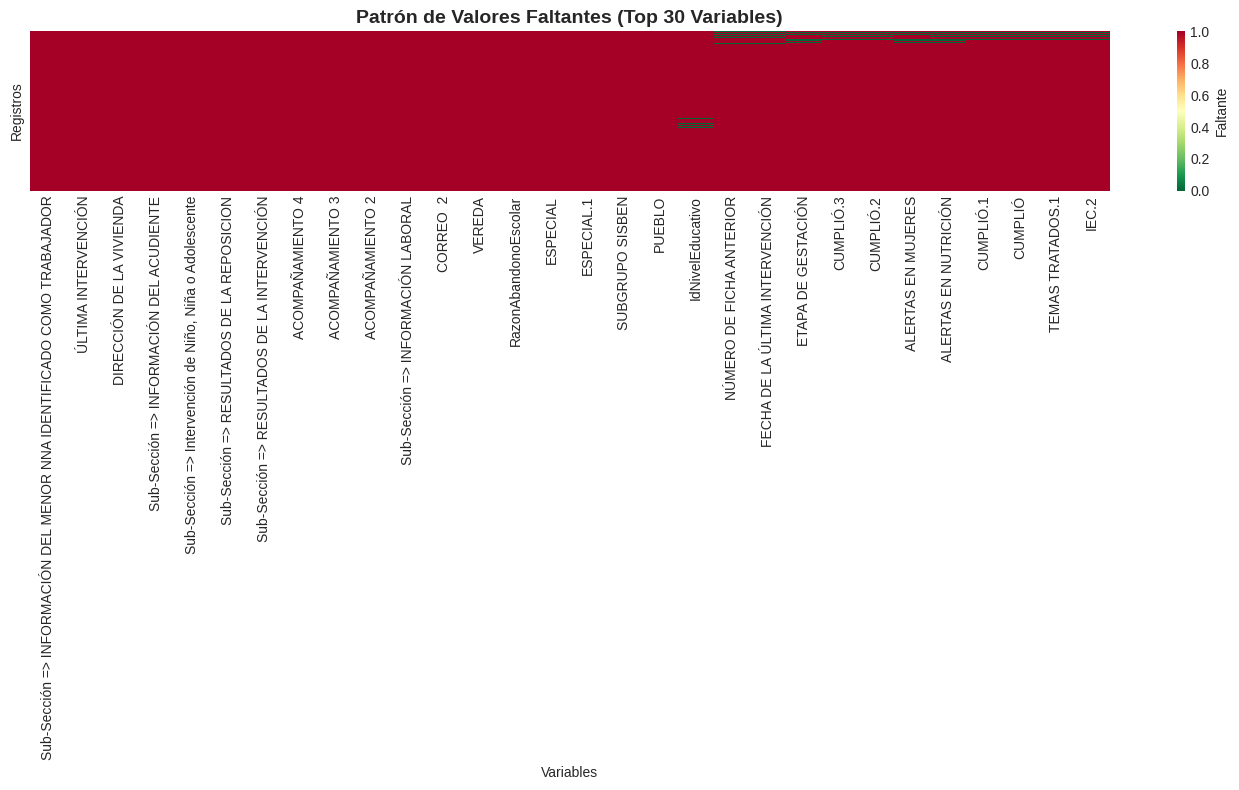

In [28]:
# ==============================================================================
# 6. ANÁLISIS DE COMPLETITUD (VALORES FALTANTES)
# ==============================================================================

print("\n" + "=" * 80)
print(" ANÁLISIS DE COMPLETITUD DE DATOS")
print("=" * 80)

# Calcular estadísticas de valores faltantes
faltantes_count = datos.isna().sum()
faltantes_pct = (faltantes_count / len(datos)) * 100
completitud_pct = 100 - faltantes_pct

# Crear tabla resumen
calidad_datos = pd.DataFrame({
    'Variable': datos.columns,
    'Valores_Faltantes': faltantes_count.values,
    'Porcentaje_Faltante': faltantes_pct.values,
    'Porcentaje_Completo': completitud_pct.values,
    'Tipo_Dato': datos.dtypes.values
}).sort_values('Porcentaje_Faltante', ascending=False)

print(f"\n Resumen de completitud:")
print(f"   - Variables 100% completas: {(completitud_pct == 100).sum()}")
print(f"   - Variables ≥80% completas: {(completitud_pct >= 80).sum()}")
print(f"   - Variables ≥40% completas: {(completitud_pct >= 40).sum()}")
print(f"   - Variables <40% completas: {(completitud_pct < 40).sum()}")

print("\n Top 20 variables con mayor % de datos faltantes:")
print(calidad_datos[['Variable', 'Porcentaje_Faltante', 'Porcentaje_Completo']].head(20).to_string(index=False))

# Visualización: Mapa de calor de valores faltantes
print("\n📊 Generando mapa de calor de valores faltantes...")
plt.figure(figsize=(14, 8))
vars_faltantes = calidad_datos[calidad_datos['Porcentaje_Faltante'] > 0]['Variable'].head(30)
sns.heatmap(datos[vars_faltantes].isna(),
            cbar=True,
            yticklabels=False,
            cmap='RdYlGn_r',
            cbar_kws={'label': 'Faltante'})
plt.title("Patrón de Valores Faltantes (Top 30 Variables)", fontsize=14, fontweight='bold')
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.tight_layout()
plt.show()

In [29]:
# ==============================================================================
# 7. DETECCIÓN DE DUPLICADOS
# ==============================================================================

print("\n" + "=" * 80)
print(" DETECCIÓN DE REGISTROS DUPLICADOS")
print("=" * 80)

duplicados = datos.duplicated().sum()
print(f"\n Registros completamente duplicados: {duplicados:,} ({(duplicados/len(datos)*100):.2f}%)")

if duplicados > 0:
    print("  Nota: Los duplicados NO se eliminan en esta fase exploratoria")
    print("   Se revisarán en la fase de preparación de datos")



 DETECCIÓN DE REGISTROS DUPLICADOS

 Registros completamente duplicados: 3,690 (6.53%)
  Nota: Los duplicados NO se eliminan en esta fase exploratoria
   Se revisarán en la fase de preparación de datos



ANÁLISIS DE VARIABLES NUMÉRICAS

 Total de variables numéricas: 24

 Estadísticas descriptivas:
                                                                         count           mean            std          min           25%           50%            75%            max  missing_%  zeros  unique
Id_fic                                                                56473.00     1097818.92      671193.91    154976.00     428856.00    1082024.00     1786453.00     2061436.00       0.00      0   51895
Ficha_fic                                                             56473.00  8296296388.09 14035958283.53 203027130.00 1120242189.00 2180257869.00  3190255554.00 41602230448.00       0.00      0   51892
.INFORMACIÓN DEL MENOR.                                                8075.00      172350.09      109978.05         0.00      75208.50     166774.00      259639.00      415721.00      85.70      2    7945
Sub-Sección => INFORMACIÓN DEL MENOR NNA IDENTIFICADO COMO TRABAJADOR     0.00 

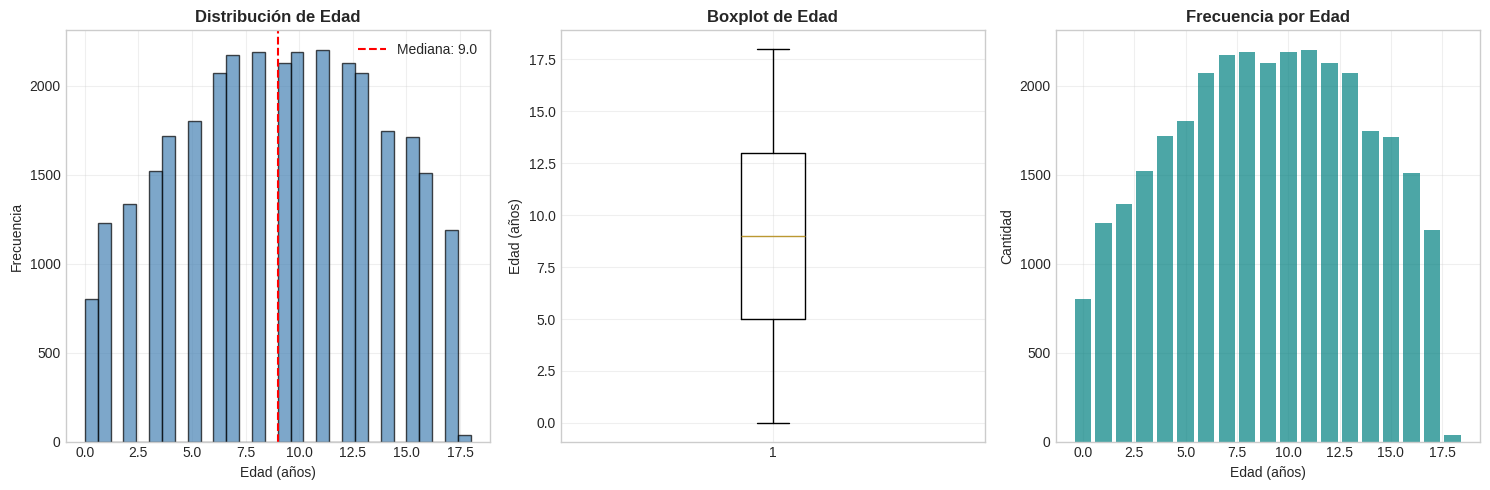


 Outliers en EDAD: 0 (0.00%)


In [30]:

# ==============================================================================
# 8. ANÁLISIS DE VARIABLES NUMÉRICAS
# ==============================================================================

print("\n" + "=" * 80)
print("ANÁLISIS DE VARIABLES NUMÉRICAS")
print("=" * 80)

vars_numericas = datos.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n Total de variables numéricas: {len(vars_numericas)}")

if len(vars_numericas) > 0:
    print("\n Estadísticas descriptivas:")
    stats = datos[vars_numericas].describe().T
    stats['missing_%'] = faltantes_pct[vars_numericas].values
    stats['zeros'] = (datos[vars_numericas] == 0).sum().values
    stats['unique'] = [datos[col].nunique() for col in vars_numericas]
    print(stats.to_string())

    # Detectar variables constantes
    vars_constantes = [col for col in vars_numericas if datos[col].nunique() <= 1]
    if vars_constantes:
        print(f"\n  Variables constantes (candidatas a eliminar): {len(vars_constantes)}")
        print(f"   {vars_constantes}")

    # Análisis específico de EDAD
    if 'EDAD' in datos.columns:
        print("\n" + "-" * 80)
        print("📊 ANÁLISIS DETALLADO: VARIABLE EDAD")
        print("-" * 80)

        edad_stats = datos['EDAD'].describe()
        print("\nEstadísticas de EDAD:")
        print(edad_stats)

        # Visualizaciones
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Histograma
        axes[0].hist(datos['EDAD'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[0].axvline(datos['EDAD'].median(), color='red', linestyle='--', label=f'Mediana: {datos["EDAD"].median():.1f}')
        axes[0].set_title("Distribución de Edad", fontweight='bold')
        axes[0].set_xlabel("Edad (años)")
        axes[0].set_ylabel("Frecuencia")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Boxplot
        axes[1].boxplot(datos['EDAD'].dropna(), vert=True)
        axes[1].set_title("Boxplot de Edad", fontweight='bold')
        axes[1].set_ylabel("Edad (años)")
        axes[1].grid(True, alpha=0.3)

        # Barras de frecuencia
        edad_freq = datos['EDAD'].value_counts().sort_index()
        axes[2].bar(edad_freq.index, edad_freq.values, color='teal', alpha=0.7)
        axes[2].set_title("Frecuencia por Edad", fontweight='bold')
        axes[2].set_xlabel("Edad (años)")
        axes[2].set_ylabel("Cantidad")
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Detección de outliers
        Q1 = datos['EDAD'].quantile(0.25)
        Q3 = datos['EDAD'].quantile(0.75)
        IQR = Q3 - Q1
        outliers = datos[(datos['EDAD'] < Q1 - 1.5*IQR) | (datos['EDAD'] > Q3 + 1.5*IQR)]['EDAD']
        print(f"\n Outliers en EDAD: {len(outliers)} ({len(outliers)/len(datos)*100:.2f}%)")
        if len(outliers) > 0:
            print(f"   Rango de outliers: [{outliers.min():.0f}, {outliers.max():.0f}]")




 ANÁLISIS DE VARIABLES CATEGÓRICAS

 Total de variables categóricas: 83

 Cardinalidad (valores únicos):
                                                       Variable  Valores_Unicos  Missing_%                        Ejemplo
                                                     TELÉFONO 1           21057      34.19                     3223185759
                                                NOMBRE DE LA UT           10859      56.44                 TIENDA DE ROPA
                                          DIRECCIÓN DEL TRABAJO            3639      88.69             KR 18     1 H   23
                                                         BARRIO            3008      17.05                      EL LUCERO
                                                       BARRIO.1            2322      31.08                      EL LUCERO
                                                      CORREO  1             577      93.03            SUBREDSUR@GMAIL.COM
                                        

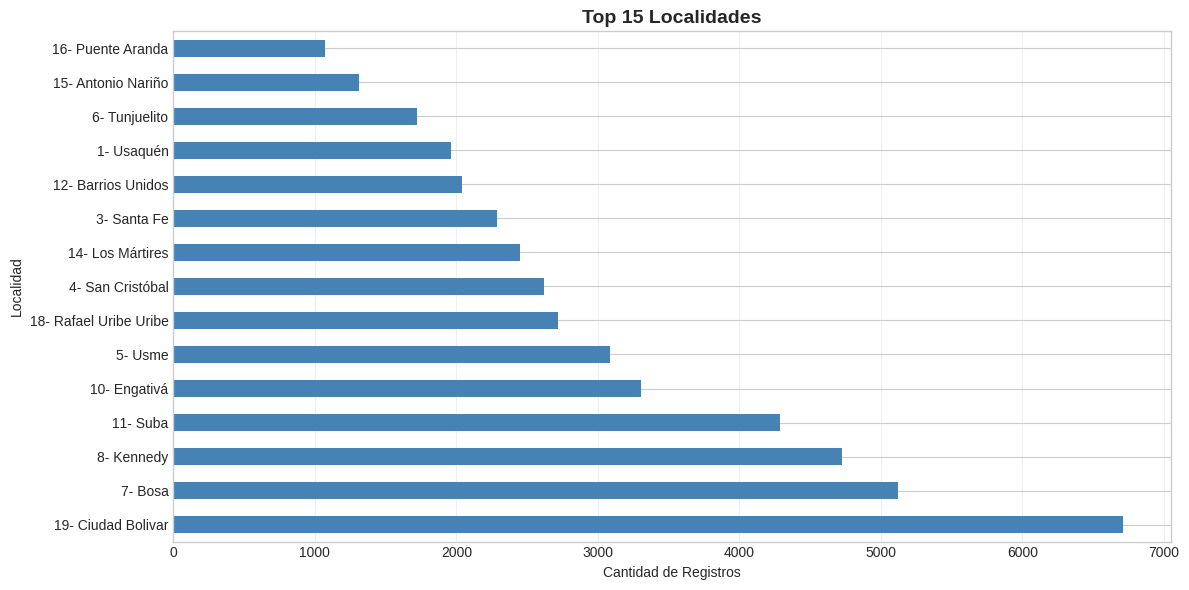


--------------------------------------------------------------------------------
ANÁLISIS DETALLADO: VARIABLE SEXO
--------------------------------------------------------------------------------

Distribución por sexo:
SEXO
1- Hombre         22956
2- Mujer          22343
3- Intersexual        1
Name: count, dtype: int64


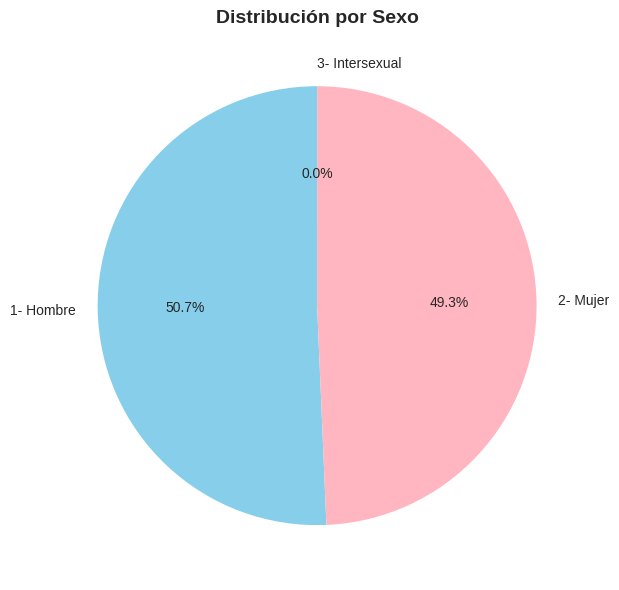

In [31]:
# ==============================================================================
# 9. ANÁLISIS DE VARIABLES CATEGÓRICAS
# ==============================================================================

print("\n" + "=" * 80)
print(" ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("=" * 80)

vars_categoricas = datos.select_dtypes(include=['object']).columns.tolist()
print(f"\n Total de variables categóricas: {len(vars_categoricas)}")

if len(vars_categoricas) > 0:
    print("\n Cardinalidad (valores únicos):")
    cardinalidad = pd.DataFrame({
        'Variable': vars_categoricas,
        'Valores_Unicos': [datos[col].nunique() for col in vars_categoricas],
        'Missing_%': [faltantes_pct[col] for col in vars_categoricas],
        'Ejemplo': [str(datos[col].dropna().iloc[0])[:30] if len(datos[col].dropna()) > 0 else 'N/A' for col in vars_categoricas]
    }).sort_values('Valores_Unicos', ascending=False)
    print(cardinalidad.to_string(index=False))

    # Variables de alta cardinalidad (posibles IDs)
    vars_alta_card = cardinalidad[cardinalidad['Valores_Unicos'] > 100]['Variable'].tolist()
    if vars_alta_card:
        print(f"\n  Variables con alta cardinalidad (>100 valores): {len(vars_alta_card)}")
        print("   Pueden ser identificadores o texto libre:")
        for v in vars_alta_card[:5]:
            print(f"   - {v}")

    # Análisis de LOCALIDAD
    if 'LOCALIDAD' in datos.columns:
        print("\n" + "-" * 80)
        print(" ANÁLISIS DETALLADO: VARIABLE LOCALIDAD")
        print("-" * 80)

        localidad_dist = datos['LOCALIDAD'].value_counts()
        print(f"\nTotal de localidades únicas: {localidad_dist.shape[0]}")
        print("\nTop 10 localidades:")
        print(localidad_dist.head(10))

        plt.figure(figsize=(12, 6))
        localidad_dist.head(15).plot(kind='barh', color='steelblue')
        plt.title("Top 15 Localidades", fontsize=14, fontweight='bold')
        plt.xlabel("Cantidad de Registros")
        plt.ylabel("Localidad")
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

    # Análisis de SEXO
    if 'SEXO' in datos.columns:
        print("\n" + "-" * 80)
        print("ANÁLISIS DETALLADO: VARIABLE SEXO")
        print("-" * 80)

        sexo_dist = datos['SEXO'].value_counts()
        print("\nDistribución por sexo:")
        print(sexo_dist)

        plt.figure(figsize=(8, 6))
        colors = ['#87CEEB', '#FFB6C1', '#D3D3D3'][:len(sexo_dist)]
        sexo_dist.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=colors)
        plt.title("Distribución por Sexo", fontsize=14, fontweight='bold')
        plt.ylabel("")
        plt.tight_layout()
        plt.show()



In [32]:
# ==============================================================================
# 10. ANÁLISIS DE CORRELACIONES (SOLO PARA REFERENCIA)
# ==============================================================================

print("\n" + "=" * 80)
print("ANÁLISIS DE CORRELACIONES (Variables Numéricas)")
print("=" * 80)

if len(vars_numericas) > 1:
    # Calcular correlaciones
    correlacion = datos[vars_numericas].corr()

    # Buscar correlaciones altas
    corr_alta = []
    for i in range(len(correlacion.columns)):
        for j in range(i+1, len(correlacion.columns)):
            if abs(correlacion.iloc[i, j]) > 0.7:
                corr_alta.append((correlacion.columns[i], correlacion.columns[j], correlacion.iloc[i, j]))

    if corr_alta:
        print(f"\n Pares con correlación fuerte (|r| > 0.7): {len(corr_alta)}")
        for var1, var2, r in corr_alta[:10]:
            print(f"   - {var1} ↔ {var2}: r = {r:.3f}")
    else:
        print("\n No se detectaron correlaciones fuertes")

    # Heatmap (solo si hay pocas variables)
    if len(vars_numericas) <= 15:
        plt.figure(figsize=(12, 10))
        sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, square=True, linewidths=1)
        plt.title("Matriz de Correlación", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()




ANÁLISIS DE CORRELACIONES (Variables Numéricas)

 Pares con correlación fuerte (|r| > 0.7): 4
   - Id_fic ↔ .INFORMACIÓN DEL MENOR.: r = 0.820
   - Id_fic ↔ ESPECIAL.1: r = -0.767
   - Ficha_fic ↔ NÚMERO DE FICHA ANTERIOR: r = 1.000
   - UPZ/UPR ↔ UPZ/UPR.1: r = 0.925


In [38]:
# ==============================================================================
# 11. SELECCIÓN DE VARIABLES PARA CLUSTERING
# ==============================================================================

print("\n" + "=" * 80)
print("SELECCIÓN DE VARIABLES PARA LA FASE DE PREPARACIÓN")
print("=" * 80)

# Criterio: Completitud >= 40%
umbral = 40
variables_seleccionadas = completitud_pct[completitud_pct >= umbral].index.tolist()

print(f"\n Variables con ≥{umbral}% completitud: {len(variables_seleccionadas)}/{len(datos.columns)}")
print(f"   Variables descartadas: {len(datos.columns) - len(variables_seleccionadas)}")

# Excluir variables de alta cardinalidad (probables IDs)
if vars_alta_card:
    variables_finales = [v for v in variables_seleccionadas if v not in vars_alta_card]
    print(f"\n Variables finales (sin alta cardinalidad): {len(variables_finales)}")
    print(f"   Variables de alta cardinalidad excluidas: {len(variables_seleccionadas) - len(variables_finales)}")
else:
    variables_finales = variables_seleccionadas
    print(f"\n No se detectaron variables de alta cardinalidad")

# Crear dataset filtrado
datos_filtrados = datos[variables_finales].copy()
print(f"\n Dataset filtrado: {datos_filtrados.shape[0]:,} × {datos_filtrados.shape[1]}")

# Composición del dataset filtrado
num_final = len(datos_filtrados.select_dtypes(include=[np.number]).columns)
cat_final = len(datos_filtrados.select_dtypes(include=['object']).columns)
print(f"\n Composición:")
print(f"   - Variables numéricas: {num_final}")
print(f"   - Variables categóricas: {cat_final}")




SELECCIÓN DE VARIABLES PARA LA FASE DE PREPARACIÓN

 Variables con ≥40% completitud: 45/115
   Variables descartadas: 70

 Variables finales (sin alta cardinalidad): 38
   Variables de alta cardinalidad excluidas: 7

 Dataset filtrado: 56,473 × 38

 Composición:
   - Variables numéricas: 5
   - Variables categóricas: 29


In [39]:
# ==============================================================================
# 11-1 LIMPIEZA FINAL DE VARIABLES PROBLEMÁTICAS
# ==============================================================================

print("\n" + "=" * 80)
print(" LIMPIEZA FINAL: ELIMINACIÓN DE VARIABLES PROBLEMÁTICAS")
print("=" * 80)

# 1. Eliminar identificadores explícitamente
ids_a_eliminar = ['Id_fic', 'Ficha_fic', 'NÚMERO DE FICHA ANTERIOR',
                  '.INFORMACIÓN DEL MENOR.', 'Usuario']

vars_ids_encontradas = [v for v in variables_finales if v in ids_a_eliminar]
if vars_ids_encontradas:
    print(f"\n Eliminando {len(vars_ids_encontradas)} identificadores:")
    for v in vars_ids_encontradas:
        print(f"   - {v}")
        if v in variables_finales:
            variables_finales.remove(v)

# 2. Eliminar variables duplicadas por alta correlación
duplicadas = {
    'UPZ/UPR.1': 'UPZ/UPR',  # Conservar UPZ/UPR
    'ESPECIAL.1': 'ESPECIAL'  # Conservar ESPECIAL
}

for var_dup, var_original in duplicadas.items():
    if var_dup in variables_finales:
        if var_original in variables_finales:
            print(f"\n Variables duplicadas detectadas:")
            print(f"   Eliminando: {var_dup} (r=0.925 con {var_original})")
            variables_finales.remove(var_dup)

# 3. Preferir variables sin faltantes cuando hay alternativas
preferencias = {
    'LOCALIDAD': 'Localidad_fic',  # Localidad_fic tiene 100% completitud
    'LOCALIDAD.1': 'Localidad_fic'
}

for var_mala, var_buena in preferencias.items():
    if var_mala in variables_finales and var_buena in datos.columns:
        if var_buena not in variables_finales:
            variables_finales.append(var_buena)
        if var_mala in variables_finales:
            print(f"\n Reemplazando {var_mala} → {var_buena} (mejor completitud)")
            variables_finales.remove(var_mala)

# 4. Actualizar dataset filtrado
datos_filtrados = datos[variables_finales].copy()

print(f"\n Dataset final optimizado:")
print(f"   - Shape: {datos_filtrados.shape[0]:,} × {datos_filtrados.shape[1]}")

num_final = len(datos_filtrados.select_dtypes(include=[np.number]).columns)
cat_final = len(datos_filtrados.select_dtypes(include=['object']).columns)
print(f"   - Numéricas: {num_final}")
print(f"   - Categóricas: {cat_final}")

# 5. Mostrar variables finales
print(f"\n VARIABLES FINALES SELECCIONADAS ({len(variables_finales)}):")
print("\nNuméricas:")
for v in datos_filtrados.select_dtypes(include=[np.number]).columns:
    print(f"   ✓ {v}")
print("\nCategóricas:")
for v in datos_filtrados.select_dtypes(include=['object']).columns:
    print(f"   ✓ {v}")


 LIMPIEZA FINAL: ELIMINACIÓN DE VARIABLES PROBLEMÁTICAS

 Eliminando 2 identificadores:
   - Id_fic
   - Ficha_fic

 Variables duplicadas detectadas:
   Eliminando: UPZ/UPR.1 (r=0.925 con UPZ/UPR)

 Reemplazando LOCALIDAD → Localidad_fic (mejor completitud)

 Reemplazando LOCALIDAD.1 → Localidad_fic (mejor completitud)

 Dataset final optimizado:
   - Shape: 56,473 × 33
   - Numéricas: 2
   - Categóricas: 27

 VARIABLES FINALES SELECCIONADAS (33):

Numéricas:
   ✓ EDAD
   ✓ UPZ/UPR

Categóricas:
   ✓ Base_Origen
   ✓ Localidad_fic
   ✓ Red_fic
   ✓ TIPO INTERVENCIÓN
   ✓ NACIONALIDAD
   ✓ SEXO
   ✓ GENERO
   ✓ ESTADO CIVIL
   ✓ CURSO DE VIDA
   ✓ ETNIA
   ✓ POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN
   ✓ OCUPACIÓN
   ✓ CATEGORÍAS DE LA DISCAPACIDAD
   ✓ VÍNCULO CON EL JEFE DE HOGAR
   ✓ AFILIACIÓN AL SGSSS
   ✓ ZONA
   ✓ BARRIO PRIORIZADO
   ✓ MANZANA DEL CUIDADO
   ✓ ESTRATO
   ✓ AFILIACIÓN AL SGSSS.1
   ✓ ESTRATO SOCIOECONÓMICO
   ✓ ZONA.1
   ✓ BARRIO PRIORIZADO.1
   ✓ MANZANA DEL CUIDADO

In [40]:
# ==============================================================================
# 11-2 ELIMINACIÓN DE VARIABLES DUPLICADAS FINALES
# ==============================================================================

print("\n" + "=" * 80)
print(" VERIFICACIÓN FINAL: ELIMINACIÓN DE VARIABLES DUPLICADAS")
print("=" * 80)

# Diccionario de variables duplicadas (eliminar la .1 o la menos completa)
duplicadas_finales = {
    'GENERO': 'SEXO',  # Mismo concepto
    'AFILIACIÓN AL SGSSS.1': 'AFILIACIÓN AL SGSSS',
    'ZONA.1': 'ZONA',
    'BARRIO PRIORIZADO.1': 'BARRIO PRIORIZADO',
    'MANZANA DEL CUIDADO.1': 'MANZANA DEL CUIDADO'
}

variables_eliminadas = []
for var_eliminar, var_conservar in duplicadas_finales.items():
    if var_eliminar in variables_finales and var_conservar in variables_finales:
        # Verificar completitud antes de eliminar
        comp_eliminar = (datos[var_eliminar].notna().sum() / len(datos)) * 100
        comp_conservar = (datos[var_conservar].notna().sum() / len(datos)) * 100

        print(f"\n Comparando variables duplicadas:")
        print(f"   - {var_conservar}: {comp_conservar:.1f}% completa")
        print(f"   - {var_eliminar}: {comp_eliminar:.1f}% completa")

        # Conservar la que tenga mejor completitud
        if comp_eliminar > comp_conservar:
            print(f" Conservando: {var_eliminar} (mejor completitud)")
            variables_finales.remove(var_conservar)
            variables_eliminadas.append(var_conservar)
        else:
            print(f"Conservando: {var_conservar}")
            variables_finales.remove(var_eliminar)
            variables_eliminadas.append(var_eliminar)

# Caso especial: ESTRATO vs ESTRATO SOCIOECONÓMICO
if 'ESTRATO' in variables_finales and 'ESTRATO SOCIOECONÓMICO' in variables_finales:
    # Verificar si son idénticas
    son_iguales = datos['ESTRATO'].equals(datos['ESTRATO SOCIOECONÓMICO'])

    if son_iguales:
        print(f"\n ESTRATO y ESTRATO SOCIOECONÓMICO son idénticas")
        print(f"   Eliminando: ESTRATO")
        variables_finales.remove('ESTRATO')
        variables_eliminadas.append('ESTRATO')
    else:
        print(f"\n ESTRATO y ESTRATO SOCIOECONÓMICO son diferentes (se conservan ambas)")

print(f"\n Variables eliminadas: {len(variables_eliminadas)}")
for v in variables_eliminadas:
    print(f"   - {v}")

# Actualizar dataset final
datos_filtrados = datos[variables_finales].copy()

print(f"\n DATASET FINAL OPTIMIZADO:")
print(f"   - Shape: {datos_filtrados.shape[0]:,} × {datos_filtrados.shape[1]}")
print(f"   - Numéricas: {len(datos_filtrados.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categóricas: {len(datos_filtrados.select_dtypes(include=['object']).columns)}")


 VERIFICACIÓN FINAL: ELIMINACIÓN DE VARIABLES DUPLICADAS

 Comparando variables duplicadas:
   - SEXO: 80.2% completa
   - GENERO: 64.5% completa
Conservando: SEXO

 Comparando variables duplicadas:
   - AFILIACIÓN AL SGSSS: 73.8% completa
   - AFILIACIÓN AL SGSSS.1: 80.2% completa
 Conservando: AFILIACIÓN AL SGSSS.1 (mejor completitud)

 Comparando variables duplicadas:
   - ZONA: 83.0% completa
   - ZONA.1: 68.9% completa
Conservando: ZONA

 Comparando variables duplicadas:
   - BARRIO PRIORIZADO: 50.2% completa
   - BARRIO PRIORIZADO.1: 44.1% completa
Conservando: BARRIO PRIORIZADO

 Comparando variables duplicadas:
   - MANZANA DEL CUIDADO: 50.2% completa
   - MANZANA DEL CUIDADO.1: 44.1% completa
Conservando: MANZANA DEL CUIDADO

 ESTRATO y ESTRATO SOCIOECONÓMICO son diferentes (se conservan ambas)

 Variables eliminadas: 5
   - GENERO
   - AFILIACIÓN AL SGSSS
   - ZONA.1
   - BARRIO PRIORIZADO.1
   - MANZANA DEL CUIDADO.1

 DATASET FINAL OPTIMIZADO:
   - Shape: 56,473 × 28
   - 

In [41]:
# ==============================================================================
# 12. EXPORTACIÓN DE RESULTADOS
# ==============================================================================

print("\n" + "=" * 80)
print(" EXPORTACIÓN DE RESULTADOS")
print("=" * 80)

# Archivo de salida
salida_excel = '/content/drive/MyDrive/Python/Proyecto NNA/datos_filtrados.xlsx'

try:
    with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
        # Hoja 1: Datos filtrados (para Notebook 2)
        datos_filtrados.to_excel(writer, index=False, sheet_name='Datos_filtrados')

        # Hoja 2: Reporte de calidad
        calidad_datos.to_excel(writer, index=False, sheet_name='Calidad_Datos')

        # Hoja 3: Variables seleccionadas
        pd.DataFrame({
            'Variable': variables_finales,
            'Tipo': datos[variables_finales].dtypes.values,
            'Completitud_%': completitud_pct[variables_finales].values
        }).to_excel(writer, index=False, sheet_name='Variables_Seleccionadas')

        # Hoja 4: Estadísticas numéricas
        if len(vars_numericas) > 0:
            datos[vars_numericas].describe().to_excel(writer, sheet_name='Stats_Numericas')

        # Hoja 5: Variables descartadas
        vars_descartadas = [v for v in datos.columns if v not in variables_finales]
        if vars_descartadas:
            pd.DataFrame({
                'Variable_Descartada': vars_descartadas,
                'Motivo': ['Completitud <40%' if completitud_pct[v] < umbral else 'Alta cardinalidad' for v in vars_descartadas],
                'Completitud_%': [completitud_pct[v] for v in vars_descartadas]
            }).to_excel(writer, index=False, sheet_name='Variables_Descartadas')

    print(f"\n Archivo exportado exitosamente:")
    print(f"    {salida_excel}")
    print(f"\n   Contiene 5 hojas:")
    print("      1. Datos_filtrados → Para usar en Notebook 2")
    print("      2. Calidad_Datos → Análisis de completitud")
    print("      3. Variables_Seleccionadas → Lista final")
    print("      4. Stats_Numericas → Estadísticas descriptivas")
    print("      5. Variables_Descartadas → Motivos de exclusión")

except Exception as e:
    print(f"\n Error al exportar: {str(e)}")


 EXPORTACIÓN DE RESULTADOS

 Archivo exportado exitosamente:
    /content/drive/MyDrive/Python/Proyecto NNA/datos_filtrados.xlsx

   Contiene 5 hojas:
      1. Datos_filtrados → Para usar en Notebook 2
      2. Calidad_Datos → Análisis de completitud
      3. Variables_Seleccionadas → Lista final
      4. Stats_Numericas → Estadísticas descriptivas
      5. Variables_Descartadas → Motivos de exclusión


In [42]:
# ==============================================================================
# 13. RESUMEN EJECUTIVO
# ==============================================================================

print("\n" + "=" * 80)
print(" RESUMEN EJECUTIVO - FASE DATA UNDERSTANDING")
print("=" * 80)

print(f"""
 HALLAZGOS PRINCIPALES:

1. DIMENSIONES:
   ✓ Registros originales: {datos.shape[0]:,}
   ✓ Variables originales: {datos.shape[1]}
   ✓ Variables seleccionadas: {len(variables_finales)} (≥{umbral}% completitud)

2. CALIDAD:
   ✓ Valores 99999 detectados: {len(vars_con_99999)} variables
   ✓ Variables 100% completas: {(completitud_pct == 100).sum()}
   ✓ Registros duplicados: {duplicados:,}

3. TIPOS DE VARIABLES:
   ✓ Numéricas: {len(vars_numericas)}
   ✓ Categóricas: {len(vars_categoricas)}
   ✓ Alta cardinalidad (excluidas): {len(vars_alta_card) if vars_alta_card else 0}

4. PRÓXIMA FASE (Notebook 2 - Data Preparation):
   → Imputación de valores faltantes
   → Codificación de variables categóricas
   → Normalización de variables numéricas
   → Preparación para clustering

  RECOMENDACIONES:
   • Revisar outliers en EDAD con expertos del negocio
   • Validar categorías con baja frecuencia en LOCALIDAD
   • Considerar agrupación de variables similares
   • Documentar todas las transformaciones aplicadas
""")

print("=" * 80)
print(" FASE DATA UNDERSTANDING COMPLETADA EDA")
print(f"Archivo listo para Notebook 2: datos_filtrados.xlsx")
print(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)



 RESUMEN EJECUTIVO - FASE DATA UNDERSTANDING

 HALLAZGOS PRINCIPALES:

1. DIMENSIONES:
   ✓ Registros originales: 56,473
   ✓ Variables originales: 115
   ✓ Variables seleccionadas: 28 (≥40% completitud)

2. CALIDAD:
   ✓ Valores 99999 detectados: 104 variables
   ✓ Variables 100% completas: 11
   ✓ Registros duplicados: 3,690

3. TIPOS DE VARIABLES:
   ✓ Numéricas: 24
   ✓ Categóricas: 83
   ✓ Alta cardinalidad (excluidas): 10

4. PRÓXIMA FASE (Notebook 2 - Data Preparation):
   → Imputación de valores faltantes
   → Codificación de variables categóricas
   → Normalización de variables numéricas
   → Preparación para clustering

  RECOMENDACIONES:
   • Revisar outliers en EDAD con expertos del negocio
   • Validar categorías con baja frecuencia en LOCALIDAD
   • Considerar agrupación de variables similares
   • Documentar todas las transformaciones aplicadas

 FASE DATA UNDERSTANDING COMPLETADA EDA
Archivo listo para Notebook 2: datos_filtrados.xlsx
Fecha: 2025-10-15 22:01:03
